Title: psf_script.ipynb

Author: Zachary Lane, Quin Aicken Davies

Date: 07/11/2025

Description: Perform PSF photometry

In [1]:
import numpy as np
import pandas as pd


from astropy.io import fits
from astropy.wcs import WCS
from astropy.table import Table
from astropy.stats import sigma_clipped_stats, SigmaClip
from astropy.nddata import NDData
from astropy.modeling.fitting import LevMarLSQFitter

from photutils.detection import DAOStarFinder
from photutils.psf import extract_stars, EPSFStars, EPSFBuilder, EPSFModel, PSFPhotometry, SourceGrouper, IterativePSFPhotometry
from photutils.background import MMMBackground, LocalBackground

from tqdm import tqdm

import warnings
from astropy.utils.exceptions import AstropyUserWarning

from astropy.wcs import FITSFixedWarning

warnings.filterwarnings('ignore', category=FITSFixedWarning)

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings('ignore', category=AstropyUserWarning,
                        message='.*fit.*not have converged.*')
warnings.filterwarnings('ignore', category=AstropyUserWarning,
                        message='.*fitting region extends beyond the star cutout image.*')
warnings.filterwarnings("ignore", category=AstropyUserWarning, message=".*data contains invalid values.*")
import glob
import os
import matplotlib.pyplot as plt

In [2]:
#Read in the data
star = 'ZZ_Psc'
# #Define Folders
main_folder = '/home/users/qai11/Documents/Reduced_files/'
output_folder = '/home/users/qai11/Documents/Reduced_files/'
#Read in the reduced science files
science_files = glob.glob(os.path.join(main_folder, f'{star}_reduced_*.fits'))
print(f'Number of reduced science files: {len(science_files)}')


Number of reduced science files: 92


In [77]:
def _build_epsf(data, stars_tbl):
    nddata = NDData(data=data, mask=~np.isfinite(data)) 
    stars = extract_stars(nddata, stars_tbl, size=31)
    print(len(nddata.data[~np.isfinite(data)]))

    all_stars = []
    for star in stars:
        all_stars.append(star)

    # try:
    all_stars_combined = EPSFStars(all_stars)

    epsf_builder = EPSFBuilder(oversampling=2, maxiters=30, 
                                progress_bar=False, smoothing_kernel='quartic', 
                                recentering_maxiters=10)
    epsf, fitted_stars = epsf_builder(all_stars_combined)

    epsf_data = epsf.data
    # epsf_data = epsf_data[2:-2, 2:-2]
    epsf_data /= np.nansum(epsf_data)
    if abs(np.nanmin(epsf_data)) >= abs(np.nanmax(epsf_data)):
        print('Bad ePSF')
        return None, None
    # except:
    #     print('Failing')
    #     return None, None
    
    return epsf_data, all_stars

def positioning(data):

    mean, median, std = sigma_clipped_stats(data, sigma=3.0)  # Adjust sigma as needed

    daofind = DAOStarFinder(fwhm=10, threshold=3.0*std)  # Adjust fwhm and threshold as needed
    sources = daofind(data) # Find sources in the image

    filtered_sources = sources[(sources['xcentroid'] > 15) & (sources['ycentroid'] > 15) & 
                            (sources['xcentroid'] < (data.shape[1] - 15) ) & 
                            (sources['ycentroid'] < (data.shape[0] - 15) )]

    '''
    Filtering sources so we only get our target
    '''

    positions = np.zeros((len(filtered_sources), 2))
    positions[:,0] = filtered_sources['xcentroid'].value
    positions[:,1] = filtered_sources['ycentroid'].value
    
    return positions, daofind

def _filter_table(positions):
    stars_tbl = Table()
    stars_tbl['x'] = positions[:,0]
    stars_tbl['y'] = positions[:,1]

    return stars_tbl

def section_epsf(data):
    
    positions, daofind = positioning(data)
    
    if len(positions[:,0]) < 1:
        return [], []

    positions = np.asarray(positions, dtype=float)
    
    stars_tbl = _filter_table(positions)
    print('Len:', len(stars_tbl))
    
    if stars_tbl is None or len(stars_tbl) == 0:
        return [], []
    
    epsf_data, all_stars = _build_epsf(data, stars_tbl)
    
    return epsf_data, daofind

def photometry(data_bkg, epsf_data, positions, daofind, progress_bar=False,
               max_iter=3, tol=1e-4):

    # 0) Guard: ePSF must be finite and reasonably sized
    if epsf_data is None or not np.all(np.isfinite(epsf_data)):
        return None 
    if min(epsf_data.shape) < 7:   # avoid postage-stamp PSFs
        return None

    # 1) Normalize once (EPSFModel handles flux as a parameter; keep PSF unit-integral)
    s = np.nansum(epsf_data)
    if not np.isfinite(s) or s <= 0:
        return None
    epsf_data = epsf_data / s

    epsf_model = EPSFModel(epsf_data, oversampling=2)

    # 2) Mask NaNs so the fitter never sees them
    nd_mask = ~np.isfinite(data_bkg)
    nddata = NDData(data_bkg, mask=nd_mask)

    bkg_estimator = LocalBackground(bkg_estimator=MMMBackground(),
                                    inner_radius=3, outer_radius=6)

    init_table = Table()
    init_table['x_init'] = positions[:, 0]
    init_table['y_init'] = positions[:, 1]

    group_maker = SourceGrouper(min_separation=2.5)
    fitter = LevMarLSQFitter()

    fitshape = (31, 31)  # 9x9 is plenty for TESS stars at your FWHM

    psf_photometry = IterativePSFPhotometry(finder=daofind, 
                                            grouper=group_maker,
                                            localbkg_estimator=bkg_estimator,
                                            psf_model=epsf_model, 
                                            fitter=fitter,
                                            fit_shape=fitshape, 
                                            aperture_radius=1.91,
                                            maxiters=max_iter,
                                            progress_bar=progress_bar)
    
    if len(init_table) == 0:
        return None

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            result_tab = psf_photometry(data_bkg, init_params=init_table, mask = nd_mask)
    except Exception as e:
        # Make the failure informative so you can see which frames go bad and why
        print(f"[photometry] Failed: {e}")
        return None

    if result_tab is None or len(result_tab) == 0:
        return None

    return result_tab

In [78]:
#Open the science files using astropy hdul
hdul = fits.open(science_files[0])
hdr = hdul[0].header
data = hdul[0].data.copy()

#run section effective point spread function
epsf_data, daofind = section_epsf(data)

# photometry

Len: 931
0


ValueError: All elements of input 'data' must be finite.

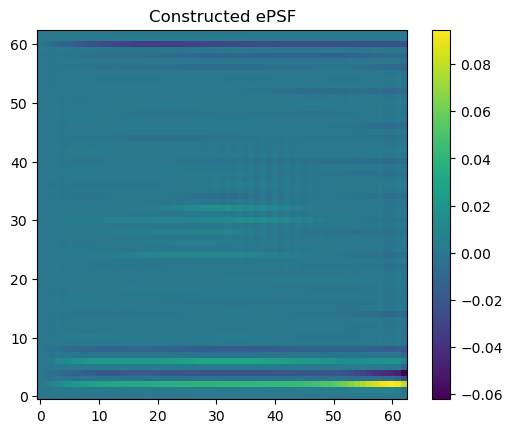

In [ ]:
# print(epsf_data)
# print(daofind)
plt.figure()
plt.imshow(epsf_data, origin='lower', cmap='viridis')
plt.colorbar()
plt.title('Constructed ePSF')
plt.show()
